
# Noteook 7 - Pre-Modeling Preparation

This notebook starts from the **FINAL FEATURE TABLE** created in Notebook 6..

Its purpose is to prepare the dataset safely for modeling while preventing data leakage.

## Included in this notebook
1. Load and Validate the fixed stratified Train/Test split created in the Feature engineering notebook.
2. Identify categorical/numeric predictors
3. Majority-class prototype averaging on train only:
   - similar negative cases are grouped by age band + ASA + BMI category + procedure group + sex
   - each fixed-size group becomes one representative row
   - continuous numeric to median
   - integer/count numeric to median + rounding
   - binary numeric / categorical to mode
   - positive cases are never averaged or removed
4. Train-only rare-category fitting
5. Train-only One-Hot Encoding
6. Train-only numeric median imputation
7. VIF analysis for multicollinearity
8. Feature Selection analyses on Train only 
9. Saving fixed Train/Test matrices for the Modeling notebook

## Not included here
- SMOTE / CTGAN (deliberately left for the Modeling notebook)
- model training
- hyperparameter tuning
- threshold tuning
- SHAP
- final model comparison

### Leakage rule
The Final Study Cohort is define using a frozen population criteria before the fixed Train/Test split.

The split is created once in the Feature Engineering notebook and is loaded unchanged here.

All subsequent data dependent processing- prototype averaging, rare-category grouping, One-Hot, imputation, VIF, feature selection- is fitted on **Train only**; the Test set remains frozen throughoutn.

### One-time manual review of automatic numeric classification

After the first full run, manually review the three automatically created numeric groups:

- `binary_cols`
- `integer_valued_continuous_cols`
- `continuous_cols`

The classification is based automatically on the values observed in the Train data. Therefore, a one-time review is required to confirm that each variable was assigned to the clinically and statistically appropriate group.

In particular, verify that variables assigned to `integer_valued_continuous_cols` are genuinely count/integer-valued features for which **median + rounding** is appropriate, and were not classified as integers only because their stored values happen to be whole numbers.

Once this classification has been reviewed and confirmed, no further manual intervention should be required unless the input schema or variable definitions change.


## Step 0 - Setup


In [35]:
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

from statsmodels.stats.outliers_influence import variance_inflation_factor

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)

RANDOM_STATE = 42
TARGET_COL = "target_binary"
CASE_ID_COL = "case_number"
TEST_SIZE = 0.3
RARE_CATEGORY_THRESHOLD = 0.03

INPUT_PATH = Path(
    r"H:\27 project\feature_engineering\fe_outputs\assuta_final_feature_table.csv"
)

OUTPUT_DIR = Path(r"H:\27 project\pre_modeling\step6_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Final Target Check

This section documents the **final outcome distribution after Cleaning and Feature Engineering**.


In [36]:
df = pd.read_csv(INPUT_PATH, encoding="utf-8-sig")
print(f"Loaded final feature table: {df.shape}")

if TARGET_COL not in df.columns:
    raise KeyError(f"Missing target column: {TARGET_COL}")

if CASE_ID_COL not in df.columns:
    raise KeyError(f"Missing case identifier: {CASE_ID_COL}")

target_missing = int(df[TARGET_COL].isna().sum())
target_unique = sorted(df[TARGET_COL].dropna().unique().tolist())

if target_missing > 0:
    raise ValueError(f"Target contains {target_missing} missing values.")

if set(target_unique) - {0, 1}:
    raise ValueError(f"Target contains unexpected values: {target_unique}")

target_counts = df[TARGET_COL].value_counts().sort_index()
target_percent = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent,
})
target_summary.index.name = "target"

display(target_summary)

n_negative = int(target_counts.get(0, 0))
n_positive = int(target_counts.get(1, 0))

imbalance_ratio = np.inf if n_positive == 0 else n_negative / n_positive

print(f"Negative cases: {n_negative}")
print(f"Positive cases: {n_positive}")
print(f"Positive prevalence: {target_percent.get(1, 0):.4f}%")
print(f"Imbalance ratio (negative:positive): {imbalance_ratio:.2f}:1")


Loaded final feature table: (31849, 92)


,count,percent
target,,
0,31708,99.557286
1,141,0.442714


Negative cases: 31708
Positive cases: 141
Positive prevalence: 0.4427%
Imbalance ratio (negative:positive): 224.88:1


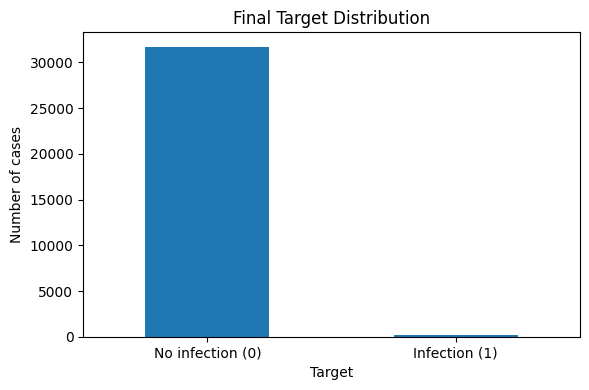

Saved target plot: H:\27 project\pre_modeling\step6_outputs\final_target_distribution.png


In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax)
ax.set_title("Final Target Distribution")
ax.set_xlabel("Target")
ax.set_ylabel("Number of cases")
ax.set_xticklabels(["No infection (0)", "Infection (1)"], rotation=0)
plt.tight_layout()

target_plot_path = OUTPUT_DIR / "final_target_distribution.png"
plt.savefig(target_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved target plot: {target_plot_path}")


## Step 1 - Loads and Validate the Locked Train/Test Split

The fixed stratifies Train/Test split was created in the Feature Engineering notebook during leakage-safe generation of the NLP risk score.

The same split is loaded here unchanged so that the held-out Test cases remain identical throughout the downstream pipeline.

After this point:
- Test is frozen and never filtered or averaged, or used to fit preprocessing decision.
- Prototype averaging and all data-dependent preprocessing are applied to Train only.


In [38]:
# Load the locked split created in the feature engineering notebook
# This is the same split used to generate the leakage-safe NLP risk_score 
# The Test set is therefore preserved unchanged throughout the downstream pipeline.
split_map = pd.read_csv(r"H:\27 project\feature_engineering\fe_outputs\locked_train_test_split.csv")
df = df.merge(split_map, on="case_number", how="left")

assert df["split"].isna().sum() == 0, "Same case_numbers are missing from the locked split file!"
assert df["split"].isin(["train", "test"]).all(), ("Unexpected values found in the split column.")

x = df.drop(columns=[TARGET_COL, "split"])
y = df[TARGET_COL].astype(int)

train_mask = (df["split"] == "train").to_numpy()
test_mask = (df["split"] == "test").to_numpy()

X_train_raw = X.loc[train_mask].reset_index(drop=True)
X_test_raw = X.loc[test_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)

split_summary = pd.DataFrame({
    "dataset": ["Train_before_reduction", "Test_frozen"],
    "rows": [len(X_train_raw), len(X_test_raw)],  
    "positive_cases": [int(y_train.sum()), int(y_test.sum())],
    "negative_cases": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "positive_percent": [float(y_train.mean() * 100), float(y_test.mean() * 100)],
})

display(split_summary)
print("Locked Train/Test split loaded successfully.")
print("Test is now frozen. All subsequent data-dependent processing is Train only.")

,dataset,rows,positive_cases,negative_cases,positive_percent
0,Train_before_reduction,22294,99,22195,0.444066
1,Test_frozen,9555,42,9513,0.439560


Locked Train/Test split loaded successfully.
Test is now frozen. All subsequent data-dependent processing is Train only.


## Step 3 - Identify categorical and numeric predictors

Categorical features will be handled with Train-only rare-category grouping and One-Hot Encoding.

Numeric features will be handled with Train-only median imputation where needed.


In [39]:
def get_model_feature_columns(df_input: pd.DataFrame) -> Tuple[List[str], List[str]]:
    categorical = []
    numeric = []

    for col in df_input.columns:
        if col == CASE_ID_COL:
            continue

        if (
            pd.api.types.is_object_dtype(df_input[col])
            or pd.api.types.is_string_dtype(df_input[col])
            or isinstance(df_input[col].dtype, pd.CategoricalDtype)
        ):
            categorical.append(col)
        elif pd.api.types.is_numeric_dtype(df_input[col]):
            numeric.append(col)

    return categorical, numeric


categorical_cols, numeric_cols = get_model_feature_columns(X_train_raw)

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")


Categorical features: 43
Numeric features: 47


## Step 4 - Majority-class averaging (Train only)

Approved by the clinical advisor: we are doing **prototype/aggregation undersampling** - group similar negative patients and replace each group with one representative row. **Positive cases are never touched, never averaged, never removed.**

**Stratification (who counts as "similar"):** age band (`"28-35", "36-45", "46-55", "56-65", "66-75", "76+") x `high_asa` x `bmi_category` x `activity_cluster` x `sex`.

**Chunk size - a fixed group size, not a target ratio:** every `PROTOTYPE_GROUP_SIZE` similar negative patients in a stratum become one representative row, **regardless of how many positives that stratum has** - including strata with **zero** positives.

**Aggregation method - by variable type, not a blind average (all three groups auto-detected from the actual Train data, not a hardcoded column-name list):**
- **Binary numeric** (only 0/1 values in the column, e.g. `has_cvc`, `high_asa`, every ICD9 `has_*` flag) -> **mode**. Never a fractional 0.37.
- **Integer-valued continuous numeric** (not binary, but every value in the source data is already a whole number - e.g. `diagnosis_count`, `procedure_count`, and typically `age`) -> **median, then rounded to the nearest integer**. Without rounding, a representative row could show `diagnosis_count = 2.5` - a value that can never occur in a real patient, undermining the "still looks like a possible patient" goal the whole method is built on.
- **Genuinely continuous numeric** (BMI, surgery duration, lab values - real fractional values already exist in the source data) -> **plain median**, no rounding (robust to skew, per the advisor's preference over mean).
- **Categorical** (sex, department, etc.) -> **mode**, as before.

**Configurable parameter:** `PROTOTYPE_GROUP_SIZE = 50` is the group size used for prototype averaging.


In [ ]:
PROTOTYPE_GROUP_SIZE = 150  

AGE_BAND_EDGES = [27, 35, 45, 55, 65, 75, 120]  
AGE_BAND_LABELS = ["28-35", "36-45", "46-55", "56-65", "66-75", "76+"]

MAJORITY_AVERAGING_STRATIFY_COLS = ["high_asa", "bmi_category", "activity_cluster", "sex"]
# age band is added automatically below as an extra stratification column.


def build_age_band(df_input: pd.DataFrame, age_col: str = "age") -> pd.Series:
    age = pd.to_numeric(df_input[age_col], errors="coerce")
    return pd.cut(age, bins=AGE_BAND_EDGES, labels=AGE_BAND_LABELS)


def classify_numeric_binary_vs_continuous(
    df_input: pd.DataFrame, numeric_cols: List[str],
) -> Tuple[List[str], List[str], List[str]]:
    """
    INFO:
    Classifies once on the full Train population (not per-chunk, where a
    continuous variable could coincidentally show only 2 values in a small
    sample), into three groups:
      - binary: every non-missing value is 0 or 1 (e.g. has_cvc, high_asa, every
        ICD9 has_* flag) -> aggregated by mode later, never mean/median, so a
        representative row never gets a meaningless fractional flag value.
      - integer_valued_continuous: not binary, but every non-missing value in the
        SOURCE data is already a whole number (e.g. diagnosis_count, age) ->
        aggregated by median, then ROUNDED to the nearest integer, so a
        representative "possible patient" never ends up with diagnosis_count=2.5
        or age=45.5 - values that never occur in the real data.
      - continuous: genuinely fractional in the source data (BMI, surgery
        duration, lab values) -> aggregated by plain median, no rounding.
    """
    binary_cols, integer_valued_continuous_cols, continuous_cols = [], [], []
    for col in numeric_cols:
        values = pd.to_numeric(df_input[col], errors="coerce").dropna().unique()
        if len(values) == 0:
            continuous_cols.append(col)
        elif set(values).issubset({0, 1}):
            binary_cols.append(col)
        elif np.all(values == np.round(values)):
            integer_valued_continuous_cols.append(col)
        else:
            continuous_cols.append(col)
    return binary_cols, integer_valued_continuous_cols, continuous_cols


def average_majority_class(
    X_train_input: pd.DataFrame,
    y_train_input: pd.Series,
    categorical_cols: List[str],
    numeric_cols: List[str],
    stratify_cols: List[str] = MAJORITY_AVERAGING_STRATIFY_COLS,
    group_size: int = PROTOTYPE_GROUP_SIZE,
    random_state: int = RANDOM_STATE,
) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    """
    INFO:
    Prototype/aggregation undersampling of y_train_input == 0 rows only, within
    strata defined by stratify_cols + an added age band. Every group_size similar
    negative rows in a stratum become ONE representative row - independent of how
    many positives that stratum has, INCLUDING strata with zero positives (a
    zero-positive stratum can still hold a large share of the negatives, so it is
    not exempt). A stratum with fewer than group_size negatives, and any leftover
    remainder that doesn't fill a full group, are kept as individual rows.

    Aggregation within an averaged chunk is type-aware, not a blind mean:
    binary numeric columns (0/1 only) -> mode; continuous/count numeric -> median;
    categorical -> mode. Positive rows pass through completely unchanged in every
    stratum - never grouped, never touched.
    """
    binary_cols, integer_valued_continuous_cols, continuous_cols = classify_numeric_binary_vs_continuous(
        X_train_input, numeric_cols,
    )

    work = X_train_input.copy()
    work["_age_band"] = build_age_band(work)
    work["_target"] = y_train_input.values

    strat_cols = [c for c in (stratify_cols + ["_age_band"]) if c in work.columns]

    kept_or_averaged_rows = []
    audit_rows = []

    for stratum_key, group in work.groupby(strat_cols, dropna=False):
        negatives = group[group["_target"] == 0]
        positives = group[group["_target"] == 1]
        n_neg = len(negatives)
        n_pos = len(positives)

        kept_or_averaged_rows.append(positives)

        n_chunks = n_neg // group_size

        if n_chunks == 0:
            kept_or_averaged_rows.append(negatives)
            audit_rows.append({
                "stratum": str(stratum_key),
                "n_negatives_before": n_neg,
                "n_positives_untouched": n_pos,
                "prototype_rows_created": 0,
                "leftover_negatives_kept": n_neg,
                "negative_rows_after": n_neg,
                "negative_rows_removed_equivalent": 0,
                "action": "kept_individual (fewer negatives than PROTOTYPE_GROUP_SIZE)",
            })
            continue

        # Deterministic but stratum-specific shuffling.
        stratum_seed = (
            random_state
            + sum(ord(ch) for ch in str(stratum_key))
        ) % (2**32 - 1)
        shuffled = negatives.sample(frac=1, random_state=stratum_seed)
        n_averaged_rows = 0

        for i in range(n_chunks):
            chunk = shuffled.iloc[i * group_size: (i + 1) * group_size]
            averaged: Dict = {}

            for col in continuous_cols:
                if col in chunk.columns:
                    averaged[col] = chunk[col].median()

            for col in integer_valued_continuous_cols:
                if col in chunk.columns:
                    median_value = chunk[col].median()
                    averaged[col] = (int(round(median_value)) if pd.notna(median_value) else np.nan)

            for col in binary_cols:
                if col in chunk.columns:
                    mode = chunk[col].mode(dropna=True)
                    averaged[col] = mode.iloc[0] if not mode.empty else np.nan

            for col in categorical_cols:
                if col in chunk.columns:
                    mode = chunk[col].mode(dropna=True)
                    averaged[col] = mode.iloc[0] if not mode.empty else np.nan

            averaged[CASE_ID_COL] = f"AVG_{stratum_key}_{i}"
            averaged["_target"] = 0
            kept_or_averaged_rows.append(pd.DataFrame([averaged]))
            n_averaged_rows += 1

        remainder = shuffled.iloc[n_chunks * group_size:]
        if len(remainder) > 0:
            kept_or_averaged_rows.append(remainder)

        audit_rows.append({
            "stratum": str(stratum_key),
            "n_negatives_before": n_neg,
            "n_positives_untouched": n_pos,
            "prototype_rows_created": n_averaged_rows,
            "leftover_negatives_kept": len(remainder),
            "negative_rows_after": n_averaged_rows + len(remainder),
            "negative_rows_removed_equivalent": n_neg - (n_averaged_rows + len(remainder)),
            "action": f"averaged_into_{n_averaged_rows}_row(s) of {group_size} "
                      f"(+{len(remainder)} leftover kept individual)",
        })

    result = pd.concat(kept_or_averaged_rows, ignore_index=True)

    y_result = result["_target"].astype(int)
    X_result = result.drop(columns=["_target", "_age_band"], errors="ignore")


    for col in integer_valued_continuous_cols:
        if col in chunk.columns:
            median_value = chunk[col].median()
            averaged[col] = (int(round(median_value)) if pd.notna(median_value) else np.nan)

    return X_result, y_result, pd.DataFrame(audit_rows)



n_train_before_averaging = len(X_train_raw)
n_negative_before_averaging = int((y_train == 0).sum())
n_positive_before_averaging = int((y_train == 1).sum())

X_train_raw, y_train, majority_averaging_audit = average_majority_class(
    X_train_raw, y_train, categorical_cols, numeric_cols,
)

n_negative_after_averaging = int((y_train == 0).sum())
n_positive_after_averaging = int((y_train == 1).sum())

if n_positive_after_averaging != n_positive_before_averaging:
    raise AssertionError(
        "Prototype averaging changed the number of positive Train cases."
    )

print(f"Train rows before prototype averaging: {n_train_before_averaging} "
      f"({n_negative_before_averaging} negative, {n_positive_before_averaging} positive)")
print(f"Train rows after prototype averaging:  {len(X_train_raw)} "
      f"({n_negative_after_averaging} negative, {n_positive_after_averaging} positive)")

display(majority_averaging_audit)

reduction_pipeline_summary = pd.DataFrame([
    {
        "stage": "Full dataset before Final Study Cohort restriction",
        "rows": 35925,
        "negative_cases": 35925 - 141,
        "positive_cases": 141,
    },
    {
        "stage": "Full dataset after Final Study Cohort restriction (age + frozen cluster list)",
        "rows": 31849,
        "negative_cases": 31849 - 141,
        "positive_cases": 141,
    },
    {
        "stage": "Train after split (already cohort-restricted)",
        "rows": n_train_before_averaging,
        "negative_cases": n_negative_before_averaging,
        "positive_cases": n_positive_before_averaging,
    },
    {
        "stage": f"Train after prototype averaging (group_size={PROTOTYPE_GROUP_SIZE})",
        "rows": len(X_train_raw),
        "negative_cases": n_negative_after_averaging,
        "positive_cases": n_positive_after_averaging,
    },
    {
        "stage": "Frozen Test (already cohort-restricted, no averaging applied)",
        "rows": len(X_test_raw),
        "negative_cases": int((y_test == 0).sum()),
        "positive_cases": int((y_test == 1).sum()),
    },
])

reduction_pipeline_summary["positive_percent"] = (
    reduction_pipeline_summary["positive_cases"]
    / reduction_pipeline_summary["rows"]
    * 100
)

print("\nReduction pipeline summary:")
display(reduction_pipeline_summary)


Train rows before prototype averaging: 22294 (22195 negative, 99 positive)
Train rows after prototype averaging:  8288 (8189 negative, 99 positive)


,stratum,n_negatives_before,n_positives_untouched,prototype_rows_created,leftover_negatives_kept,negative_rows_after,negative_rows_removed_equivalent,action
0,"(np.float64(0.0), 'normal', 'אורטופדיה', '28-35')",31,0,0,31,31,0,kept_individual (fewer negatives than PROTOTYP...
1,"(np.float64(0.0), 'normal', 'אורטופדיה', '36-45')",64,1,0,64,64,0,kept_individual (fewer negatives than PROTOTYP...
2,"(np.float64(0.0), 'normal', 'אורטופדיה', '46-55')",101,0,0,101,101,0,kept_individual (fewer negatives than PROTOTYP...
3,"(np.float64(0.0), 'normal', 'אורטופדיה', '56-65')",156,0,1,6,7,149,averaged_into_1_row(s) of 150 (+6 leftover kep...
4,"(np.float64(0.0), 'normal', 'אורטופדיה', '66-75')",183,2,1,33,34,149,averaged_into_1_row(s) of 150 (+33 leftover ke...
...,...,...,...,...,...,...,...,...
227,"(np.float64(nan), nan, 'כירורגיה כללית', '36-45')",419,0,2,119,121,298,averaged_into_2_row(s) of 150 (+119 leftover k...
228,"(np.float64(nan), nan, 'כירורגיה כללית', '46-55')",585,0,3,135,138,447,averaged_into_3_row(s) of 150 (+135 leftover k...
229,"(np.float64(nan), nan, 'כירורגיה כללית', '56-65')",544,0,3,94,97,447,averaged_into_3_row(s) of 150 (+94 leftover ke...
230,"(np.float64(nan), nan, 'כירורגיה כללית', '66-75')",519,0,3,69,72,447,averaged_into_3_row(s) of 150 (+69 leftover ke...



Reduction pipeline summary:


,stage,rows,negative_cases,positive_cases,positive_percent
0,Full dataset before Final Study Cohort restric...,35925,35784,141,0.392484
1,Full dataset after Final Study Cohort restrict...,31849,31708,141,0.442714
2,Train after split (already cohort-restricted),22294,22195,99,0.444066
3,Train after prototype averaging (group_size=150),8288,8189,99,1.194498
4,"Frozen Test (already cohort-restricted, no ave...",9555,9513,42,0.439560


## Step 5 - Rare-category grouping fitted on Train only

A category is considered rare if its frequency in **Train** is below the configured threshold.

The learned rare-value list is then applied unchanged to Test.

This avoids allowing Test data to influence preprocessing decisions.


In [41]:
def fit_rare_category_map(
    train_df: pd.DataFrame,
    columns: List[str],
    threshold: float = RARE_CATEGORY_THRESHOLD,
) -> Dict[str, List[str]]:
    rare_map = {}

    for col in columns:
        freq = train_df[col].value_counts(normalize=True, dropna=True)
        rare_values = freq[freq < threshold].index.tolist()
        # if only one rare category exists, keep it unchanged
        rare_map[col] = rare_values if len(rare_values) > 1 else []

    return rare_map


def apply_rare_category_map(
    df_input: pd.DataFrame,
    rare_map: Dict[str, List[str]],
    other_label: str = "Other",
) -> pd.DataFrame:
    result = df_input.copy()

    for col, rare_values in rare_map.items():
        if col not in result.columns:
            continue
        if rare_values:
            result[col] = result[col].where(
                ~result[col].isin(rare_values),
                other_label,
            )

    return result


rare_map = fit_rare_category_map(X_train_raw, categorical_cols)

X_train_grouped = apply_rare_category_map(X_train_raw, rare_map)
X_test_grouped = apply_rare_category_map(X_test_raw, rare_map)

rare_category_audit = pd.DataFrame([
    {
        "column": col,
        "n_rare_train_categories": len(values),
        "rare_values": " | ".join(map(str, values)),
    }
    for col, values in rare_map.items()
])

display(rare_category_audit.head(30))


,column,n_rare_train_categories,rare_values
0,activity_cluster,0,
1,admission_weekday,0,
2,department,5,צינתורים | הדמייה פולשנית | מח' אורטופדיה א'/נ...
3,surgeon_specialization,14,"אורטופדיה,כאב | כירורגיה פלסטית | אורולוגיה | ..."
4,payment _by,43,ביטוח מגדל | כללית מושלם | קופח מאוחדת שבן | ב...
5,diagnosis_1,680,"unilateral inguinal hernia, right | hyperlipid..."
6,diagnosis_2,496,umbilical hernia | bilateral inguinal hernia |...
7,diagnosis_icd9_2,332,272.4 | 250 | 278.01 | 715.9 | 715.36 | 550.9 ...
8,diagnosis_3,353,"tv-cad, triple vessel coronary artery disease ..."
9,diagnosis_icd9_3,253,401.9 | 414 | 272.4 | 715.36 | 550.9 | 414.9 |...


## Step 6 - One-Hot Encoding fitted on Train only

One-Hot Encoding converts categorical values into binary indicator columns.

The encoder is fitted on Train only, and the same learned categories are applied to Test.

`handle_unknown="ignore"` prevents unseen Test categories from breaking the pipeline.


`__MISSING__` is used only as a technical category for categorical predictors that remain missing after Cleaning. This does **not** mean the source value was erroneous; Dr. Manor confirmed that missingness may legitimately occur in several clinical/categorical fields.


In [42]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

train_cat = (
    X_train_grouped[categorical_cols]
    .astype("string")
    .fillna("__MISSING__")
)

test_cat = (
    X_test_grouped[categorical_cols]
    .astype("string")
    .fillna("__MISSING__")
)

encoder.fit(train_cat)

train_encoded_array = encoder.transform(train_cat)
test_encoded_array = encoder.transform(test_cat)

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

X_train_ohe = pd.DataFrame(
    train_encoded_array,
    columns=encoded_feature_names,
    index=X_train_grouped.index,
)

X_test_ohe = pd.DataFrame(
    test_encoded_array,
    columns=encoded_feature_names,
    index=X_test_grouped.index,
)

print(f"Categorical columns before One-Hot: {len(categorical_cols)}")
print(f"One-Hot columns created: {len(encoded_feature_names)}")


Categorical columns before One-Hot: 43
One-Hot columns created: 214


## Step 7 - Numeric median imputation fitted on Train only

For numeric missing values that remain after Cleaning, the median is calculated from **Train only** and the exact same Train median is then applied to Test.

Explanation:
- In many clinical fields, a missing value may legitimately occur and is **not automatically a data error**.
- Cleaning therefore preserves such missing values rather than inventing a clinical meaning.
- When a numeric predictor still requires a usable value for modeling, the statistical imputation is learned from Train only here.
- Fields for which Dr. Manor stated that missingness indicates an **error/problem** should first be surfaced in the Cleaning audit and investigated. This step does not reinterpret those gaps as clinically normal.

Columns that are entirely missing in Train are reported separately instead of receiving an invented value.


In [43]:
DROP_THRESHOLD = 0.90
FLAG_THRESHOLD = 0.50

train_numeric = X_train_grouped[numeric_cols].copy()
test_numeric = X_test_grouped[numeric_cols].copy()

for col in numeric_cols:
    miss_rate = train_numeric[col].isna().mean()
    if miss_rate > DROP_THRESHOLD:
        train_numeric.drop(columns=col, inplace=True)
        test_numeric.drop(columns=col, inplace=True)
        continue
    if miss_rate > FLAG_THRESHOLD:
        train_numeric[col + "_was_missing"] = train_numeric[col].isna().astype(int)
        test_numeric[col + "_was_missing"] = test_numeric[col].isna().astype(int)

In [44]:

numeric_medians = {}
all_missing_numeric_cols = []

for col in train_numeric.columns:
    median_value = train_numeric[col].median()

    if pd.isna(median_value):
        all_missing_numeric_cols.append(col)
        continue

    numeric_medians[col] = float(median_value)

imputation_rows = []

for col, median_value in numeric_medians.items():
    train_missing_before = int(train_numeric[col].isna().sum())
    test_missing_before = int(test_numeric[col].isna().sum())

    train_numeric[col] = train_numeric[col].fillna(median_value)
    test_numeric[col] = test_numeric[col].fillna(median_value)

    imputation_rows.append({
        "column": col,
        "train_median": median_value,
        "train_values_filled": train_missing_before,
        "test_values_filled": test_missing_before,
    })

numeric_imputation_audit = pd.DataFrame(imputation_rows)

if all_missing_numeric_cols:
    print("WARNING: numeric columns 100% missing in Train - DROPPED from the model "
          "matrices (median imputation cannot help; keeping them would leave NaN in "
          "X_train/X_test and crash downstream steps like Mutual Information):")
    print(all_missing_numeric_cols)
    train_numeric = train_numeric.drop(columns=all_missing_numeric_cols)
    test_numeric = test_numeric.drop(columns=all_missing_numeric_cols)

display(numeric_imputation_audit.head(50))


,column,train_median,train_values_filled,test_values_filled
0,age,61.700000,0,0
1,diagnosis_icd9_1,530.810000,1155,835
2,diagnosis_icd9_5,0.000000,0,0
3,procedure_icd9_1,51.230000,220,239
4,procedure_icd9_2,0.000000,0,0
5,procedure_icd9_3,0.000000,0,0
6,procedure_icd9_4,0.000000,0,0
7,procedure_icd9_5,0.000000,0,0
8,preop_session_date_days_from_reference,-2.502778,1635,1787
9,preop_asa_value,2.000000,949,1229


## Step 8 - Build fixed model matrices

The final matrices combine:
- imputed numeric features,
- One-Hot encoded categorical features.

`case_number` is saved separately as a reference key and is not used as a predictor.


In [45]:
train_case_ids = X_train_raw[CASE_ID_COL].copy()
test_case_ids = X_test_raw[CASE_ID_COL].copy()

X_train = pd.concat(
    [
        train_numeric.reset_index(drop=True),
        X_train_ohe.reset_index(drop=True),
    ],
    axis=1,
)

X_test = pd.concat(
    [
        test_numeric.reset_index(drop=True),
        X_test_ohe.reset_index(drop=True),
    ],
    axis=1,
)

print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape:  {X_test.shape}")


Final X_train shape: (8288, 266)
Final X_test shape:  (9555, 266)


## Step 9 - VIF analysis

**VIF = Variance Inflation Factor.**

It checks whether numeric predictors are strongly explained by other numeric predictors.

Interpretation guideline:
- around 1 to little multicollinearity
- 1-5 to usually acceptable
- >5 to review
- >10 to strong multicollinearity concern

VIF is especially relevant to Logistic Regression.

No feature is deleted automatically. The output is an audit for review.


In [46]:
def calculate_vif(
    df_numeric: pd.DataFrame,
    max_features: int = 100,
) -> pd.DataFrame:
    """
    INFO:
    VIF can be computationally expensive with very wide matrices.

    Therefore this function uses original numeric predictors only, not all One-Hot
    dummy columns. Constant / near-constant columns are excluded.
    """
    work = df_numeric.copy()

    # Remove columns with zero variance.
    valid_cols = [
        col for col in work.columns
        if work[col].nunique(dropna=False) > 1
    ]
    work = work[valid_cols]

    # Optional safety cap for very wide numeric spaces.
    if len(work.columns) > max_features:
        variances = work.var().sort_values(ascending=False)
        work = work[variances.head(max_features).index.tolist()]

    if work.empty:
        return pd.DataFrame(columns=["feature", "VIF"])

    work = work.astype(float)

    rows = []

    for i, col in enumerate(work.columns):
        try:
            vif_value = variance_inflation_factor(work.values, i)
        except Exception:
            vif_value = np.nan

        rows.append({
            "feature": col,
            "VIF": vif_value,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


vif_results = calculate_vif(train_numeric)

display(vif_results.head(30))


,feature,VIF
0,has_cvc,inf
1,invasive_device_count,inf
2,has_drain,inf
3,has_catheter,inf
4,added1_lowest_temp_in_surgery_value_(original),1.347449e+04
5,catheter_route_not_done,5.931240e+03
6,preop_sodium_value,5.556832e+03
7,preop_hba1c_value,3.942318e+02
8,preop_potassium_value,2.343654e+02
9,preop_hemoglobin_value,1.407128e+02


## Step 10 - Feature Selection analyses on Train only

This notebook creates **selection evidence**, not an irreversible final deletion rule.

We calculate:
1. Mutual Information
2. L1-regularized Logistic Regression coefficients

These are complementary views:
- Mutual Information can capture non-linear associations.
- L1 Logistic Regression can shrink weak coefficients toward zero.

The final feature set should be decided together with clinical relevance and model behavior.


In [47]:
# -----------------------------
# Mutual Information
# -----------------------------
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=RANDOM_STATE,
)

mutual_information_results = (
    pd.DataFrame({
        "feature": X_train.columns,
        "mutual_information": mi_scores,
    })
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

print("Top Mutual Information features:")
display(mutual_information_results.head(30))


Top Mutual Information features:


,feature,mutual_information
0,added1_detected_pathogen_specimen_source_Unknown,0.017497
1,detected_pathogen_Unknown,0.016260
2,procedure_icd9_1,0.014758
3,invasive_device_count,0.014305
4,detected_pathogen_Other,0.013134
5,added1_detected_pathogen_specimen_source_Other,0.012534
6,added1_mrsa_result_Unknown,0.011401
7,catheter_route_not_done,0.010525
8,catheter_task_name___MISSING__,0.008853
9,diagnosis_icd9_1,0.008591


In [48]:
# -----------------------------
# L1 Logistic Regression
# -----------------------------
# INFO: scaled for THIS ANALYSIS ONLY - L1 compares coefficient magnitudes across
# features, which is only meaningful when every feature is on the same scale.
# Without this, age/BMI/surgery-duration (wide numeric ranges) would be unfairly
# under-penalized relative to One-Hot 0/1 columns. X_train itself (used for MI
# above and for the saved handoff matrices in Step 12) is NOT modified - scaling
# happens on a separate copy, local to this cell.
l1_scaler = StandardScaler()
X_train_l1_scaled = l1_scaler.fit_transform(X_train)

l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=2000,
)

l1_model.fit(X_train_l1_scaled, y_train)

l1_results = (
    pd.DataFrame({
        "feature": X_train.columns,
        "l1_coefficient": l1_model.coef_[0],
        "abs_l1_coefficient": np.abs(l1_model.coef_[0]),
    })
    .sort_values("abs_l1_coefficient", ascending=False)
    .reset_index(drop=True)
)

print("Top L1 Logistic Regression features (fit on standardized Train - see note above):")
display(l1_results.head(30))


Top L1 Logistic Regression features (fit on standardized Train - see note above):


,feature,l1_coefficient,abs_l1_coefficient
0,surgeon_specialization_כיר' בית חזה,4.498015,4.498015
1,"procedure_1_thr, total hip replacement",-2.973999,2.973999
2,added1_anesthesia_type_spinal,-2.103077,2.103077
3,activity_cluster_אורטופדיה,1.625851,1.625851
4,recovery_bed_pacu-8,-1.506047,1.506047
5,recovery_bed___MISSING__,-1.447481,1.447481
6,detected_pathogen_Unknown,-1.277150,1.277150
7,bmi_category_normal,-1.247662,1.247662
8,payment _by_קופח מכבי שבן,-1.246878,1.246878
9,detected_pathogen_Other,1.236101,1.236101


## Step 11 - Combined feature-selection review table

This table combines:
- Mutual Information score
- L1 coefficient magnitude

It is for review before modeling.

No automatic "keep/drop" decision is enforced here because clinically important features should not be removed blindly by one statistical threshold.


In [49]:
feature_selection_review = mutual_information_results.merge(
    l1_results,
    on="feature",
    how="outer",
)

feature_selection_review["mi_rank"] = (
    feature_selection_review["mutual_information"]
    .rank(ascending=False, method="min")
)

feature_selection_review["l1_rank"] = (
    feature_selection_review["abs_l1_coefficient"]
    .rank(ascending=False, method="min")
)

feature_selection_review["mean_rank"] = (
    feature_selection_review[["mi_rank", "l1_rank"]]
    .mean(axis=1)
)

feature_selection_review = (
    feature_selection_review
    .sort_values("mean_rank")
    .reset_index(drop=True)
)

display(feature_selection_review.head(50))


,feature,mutual_information,l1_coefficient,abs_l1_coefficient,mi_rank,l1_rank,mean_rank
0,detected_pathogen_Unknown,0.016260,-1.277150,1.277150,2.0,7.0,4.5
1,detected_pathogen_Other,0.013134,1.236101,1.236101,5.0,10.0,7.5
2,surgeon_specialization_כיר' בית חזה,0.005425,4.498015,4.498015,24.0,1.0,12.5
3,added1_mrsa_result_Unknown,0.011401,-0.946177,0.946177,7.0,21.0,14.0
4,recovery_bed___MISSING__,0.005359,-1.447481,1.447481,25.0,6.0,15.5
5,has_cvc,0.006459,1.036677,1.036677,18.0,18.0,18.0
6,diagnosis_icd9_1,0.008591,-0.647775,0.647775,10.0,40.0,25.0
7,added1_detected_pathogen_specimen_source_Unknown,0.017497,0.586080,0.586080,1.0,53.0,27.0
8,surgery_bed_number,0.005432,-0.688036,0.688036,23.0,36.0,29.5
9,nlp_tfidf_logreg_risk_score,0.007910,-0.594716,0.594716,12.0,50.0,31.0


## Step 12 - Save Step 6 outputs

These outputs are the fixed handoff to the modeling notebook.


In [50]:
X_TRAIN_PATH = OUTPUT_DIR / "X_train.csv"
X_TEST_PATH = OUTPUT_DIR / "X_test.csv"
Y_TRAIN_PATH = OUTPUT_DIR / "y_train.csv"
Y_TEST_PATH = OUTPUT_DIR / "y_test.csv"

TRAIN_IDS_PATH = OUTPUT_DIR / "train_case_ids.csv"
TEST_IDS_PATH = OUTPUT_DIR / "test_case_ids.csv"

AUDIT_PATH = OUTPUT_DIR / "step6_pre_modeling_audit.xlsx"

X_train.to_csv(X_TRAIN_PATH, index=False, encoding="utf-8-sig")
X_test.to_csv(X_TEST_PATH, index=False, encoding="utf-8-sig")

y_train.to_frame(TARGET_COL).to_csv(
    Y_TRAIN_PATH, index=False, encoding="utf-8-sig"
)
y_test.to_frame(TARGET_COL).to_csv(
    Y_TEST_PATH, index=False, encoding="utf-8-sig"
)

train_case_ids.to_frame(CASE_ID_COL).to_csv(
    TRAIN_IDS_PATH, index=False, encoding="utf-8-sig"
)
test_case_ids.to_frame(CASE_ID_COL).to_csv(
    TEST_IDS_PATH, index=False, encoding="utf-8-sig"
)

audit_tables = {
    "target_summary": target_summary.reset_index(),
    "split_summary": split_summary,
    "prototype_averaging": majority_averaging_audit,
    "reduction_pipeline": reduction_pipeline_summary,
    "rare_categories": rare_category_audit,
    "numeric_imputation": numeric_imputation_audit,
    "vif": vif_results,
    "mutual_information": mutual_information_results,
    "l1_logistic": l1_results,
    "feature_selection_review": feature_selection_review,
    "final_features": pd.DataFrame({"feature": X_train.columns}),
}

with pd.ExcelWriter(AUDIT_PATH, engine="openpyxl") as writer:
    for sheet_name, table in audit_tables.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print(f"Saved outputs to: {OUTPUT_DIR}")
print(f"Audit workbook: {AUDIT_PATH}")


Saved outputs to: H:\27 project\pre_modeling\step6_outputs
Audit workbook: H:\27 project\pre_modeling\step6_outputs\step6_pre_modeling_audit.xlsx


## Step 13 - Final validation gate

If this gate passes, Step 6 is ready to hand off to the modeling notebook.


In [ ]:
print("=" * 72)
print("FINAL STEP 6 VALIDATION GATE")
print("=" * 72)

ok = True

if list(X_train.columns) != list(X_test.columns):
    ok = False
    print("FAIL: X_train and X_test columns differ.")
else:
    print("OK: X_train and X_test have identical columns.")

if len(X_train) != len(y_train):
    ok = False
    print("FAIL: X_train / y_train row mismatch.")
else:
    print("OK: X_train and y_train row counts match.")

if len(X_test) != len(y_test):
    ok = False
    print("FAIL: X_test / y_test row mismatch.")
else:
    print("OK: X_test and y_test row counts match.")

if X_train.isna().sum().sum() > 0:
    ok = False
    print("FAIL: missing values remain in X_train.")
else:
    print("OK: no missing values in X_train.")

if X_test.isna().sum().sum() > 0:
    ok = False
    print("FAIL: missing values remain in X_test.")
else:
    print("OK: no missing values in X_test.")

non_numeric_train = [
    col for col in X_train.columns
    if not pd.api.types.is_numeric_dtype(X_train[col])
]

if non_numeric_train:
    ok = False
    print("FAIL: non-numeric columns remain in X_train:", non_numeric_train)
else:
    print("OK: X_train is fully numeric.")

if y_train.mean() == 0 or y_test.mean() == 0:
    ok = False
    print("FAIL: one split contains no positive cases.")
else:
    print("OK: positive cases exist in both Train and Test.")


# Test must remain exactly the split that was originally created.
expected_test_rows = int(
    split_summary.loc[split_summary["dataset"] == "Test_frozen", "rows"].iloc[0]
)
expected_test_positives = int(
    split_summary.loc[
        split_summary["dataset"] == "Test_frozen", "positive_cases"
    ].iloc[0]
)

if len(X_test) != expected_test_rows:
    ok = False
    print(
        f"FAIL: frozen Test row count changed "
        f"({expected_test_rows} -> {len(X_test)})."
    ) 
else:
    print("OK: frozen Test row count remained unchanged.")

if int(y_test.sum()) != expected_test_positives:
    ok = False
    print("FAIL: frozen Test positive count changed.")
else:
    print("OK: frozen Test target distribution remained unchanged.")

if int(y_train.sum()) != n_positive_before_averaging:
    ok = False
    print(
        "FAIL: prototype averaging changed the number of positive Train cases."
    )
else:
    print("OK: all positive Train cases were preserved through prototype averaging.")

if len(train_case_ids) != len(X_train):
    ok = False
    print("FAIL: train_case_ids length does not match X_train.")
else:
    print("OK: train_case_ids align with X_train.")

if len(test_case_ids) != len(X_test):
    ok = False
    print("FAIL: test_case_ids length does not match X_test.")
else:
    print("OK: test_case_ids align with X_test.")



print()
if ok:
    print("READY FOR MODELING.")
else:
    print("NOT READY — review FAIL item(s) above.")


FINAL STEP 6 VALIDATION GATE
OK: X_train and X_test have identical columns.
OK: X_train and y_train row counts match.
OK: X_test and y_test row counts match.
OK: no missing values in X_train.
OK: no missing values in X_test.
OK: X_train is fully numeric.
OK: positive cases exist in both Train and Test.
OK: frozen Test row count remained unchanged.
OK: frozen Test target distribution remained unchanged.
OK: all positive Train cases were preserved through prototype averaging.
OK: train_case_ids align with X_train.
OK: test_case_ids align with X_test.

READY FOR MODELING.
